# XGBoost Baseline - Playground Series S6E4

**Target:** `Irrigation_Need` (Low / Medium / High)  
**Metric:** Balanced Accuracy  
**Strategy:** StratifiedKFold + class weight handling

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print(f"Train: {train.shape}, Test: {test.shape}")

Train: (630000, 21), Test: (270000, 20)


## 1. Preprocessing

In [2]:
TARGET = 'Irrigation_Need'
CAT_COLS = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
            'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

# Label encode target
target_le = LabelEncoder()
y = target_le.fit_transform(train[TARGET])
print(f"Target classes: {dict(zip(target_le.classes_, target_le.transform(target_le.classes_)))}")

# Label encode categoricals
label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])
    label_encoders[col] = le

# Features
drop_cols = ['id', TARGET]
feature_cols = [c for c in train.columns if c not in drop_cols]
X = train[feature_cols]
X_test = test[feature_cols]

print(f"Features: {len(feature_cols)}")
print(f"X: {X.shape}, X_test: {X_test.shape}")

# Class weights for imbalance
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y)
print(f"\nTarget distribution: {np.bincount(y)}")
print(f"Unique sample weights: {np.unique(sample_weights).round(4)}")

Target classes: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Features: 19
X: (630000, 19), X_test: (270000, 19)

Target distribution: [ 21009 369917 239074]
Unique sample weights: [0.5677 0.8784 9.9957]


## 2. Training (5-Fold StratifiedKFold)

In [3]:
N_FOLDS = 5
SEED = 42

xgb_params = {
    'n_estimators': 1000,
    'max_depth': 8,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'objective': 'multi:softprob',
    'num_class': 3,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'random_state': SEED,
    'n_jobs': -1,
    'verbosity': 0,
    'enable_categorical': False,
}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_preds = np.zeros((len(X), 3))
test_preds = np.zeros((len(X_test), 3))
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    sw_tr = sample_weights[train_idx]

    model = XGBClassifier(**xgb_params)
    model.fit(
        X_tr, y_tr,
        sample_weight=sw_tr,
        eval_set=[(X_val, y_val)],
        verbose=100,
    )

    oof_preds[val_idx] = model.predict_proba(X_val)
    test_preds += model.predict_proba(X_test) / N_FOLDS

    val_pred_labels = oof_preds[val_idx].argmax(axis=1)
    score = balanced_accuracy_score(y_val, val_pred_labels)
    fold_scores.append(score)
    print(f"Fold {fold}: Balanced Accuracy = {score:.5f}")
    print(f"  Val class distribution: {np.bincount(y_val)}")
    print(f"  Pred class distribution: {np.bincount(val_pred_labels)}\n")

oof_labels = oof_preds.argmax(axis=1)
overall_score = balanced_accuracy_score(y, oof_labels)
print(f"{'='*50}")
print(f"Overall OOF Balanced Accuracy: {overall_score:.5f}")
print(f"Mean Fold Score: {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})")
print(f"\nOOF Prediction distribution: {np.bincount(oof_labels)}")
print(f"Actual distribution:         {np.bincount(y)}")

[0]	validation_0-mlogloss:1.04888
[100]	validation_0-mlogloss:0.09655
[200]	validation_0-mlogloss:0.06794
[300]	validation_0-mlogloss:0.06183
[400]	validation_0-mlogloss:0.05920
[500]	validation_0-mlogloss:0.05778
[600]	validation_0-mlogloss:0.05693
[700]	validation_0-mlogloss:0.05647
[800]	validation_0-mlogloss:0.05619
[900]	validation_0-mlogloss:0.05609
[999]	validation_0-mlogloss:0.05619
Fold 0: Balanced Accuracy = 0.96528
  Val class distribution: [ 4201 73984 47815]
  Pred class distribution: [ 4046 74728 47226]

[0]	validation_0-mlogloss:1.04896
[100]	validation_0-mlogloss:0.09738
[200]	validation_0-mlogloss:0.06938
[300]	validation_0-mlogloss:0.06345
[400]	validation_0-mlogloss:0.06068
[500]	validation_0-mlogloss:0.05922
[600]	validation_0-mlogloss:0.05834
[700]	validation_0-mlogloss:0.05787
[800]	validation_0-mlogloss:0.05765
[900]	validation_0-mlogloss:0.05759
[999]	validation_0-mlogloss:0.05769
Fold 1: Balanced Accuracy = 0.96715
  Val class distribution: [ 4202 73984 47814]


## 3. Analysis

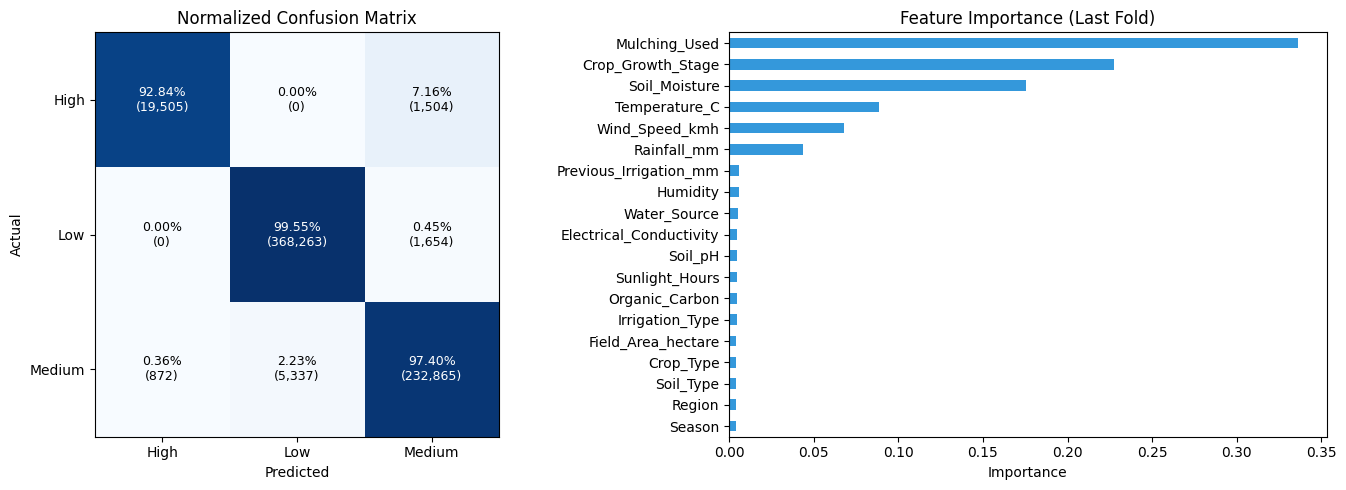

              precision    recall  f1-score   support

        High       0.96      0.93      0.94     21009
         Low       0.99      1.00      0.99    369917
      Medium       0.99      0.97      0.98    239074

    accuracy                           0.99    630000
   macro avg       0.98      0.97      0.97    630000
weighted avg       0.99      0.99      0.99    630000



In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y, oof_labels)
cm_pct = cm / cm.sum(axis=1, keepdims=True)
im = axes[0].imshow(cm_pct, cmap='Blues', vmin=0, vmax=1)
class_names = target_le.classes_
axes[0].set_xticks(range(3))
axes[0].set_yticks(range(3))
axes[0].set_xticklabels(class_names)
axes[0].set_yticklabels(class_names)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Normalized Confusion Matrix')
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f'{cm_pct[i,j]:.2%}\n({cm[i,j]:,})',
                     ha='center', va='center', fontsize=9,
                     color='white' if cm_pct[i,j] > 0.5 else 'black')

# Feature importance
importance = model.feature_importances_
feat_imp = pd.Series(importance, index=feature_cols).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Feature Importance (Last Fold)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print(classification_report(y, oof_labels, target_names=class_names))

## 4. Submission

In [5]:
test_labels = test_preds.argmax(axis=1)
test_label_names = target_le.inverse_transform(test_labels)

submission = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': test_label_names
})

print(f"Submission shape: {submission.shape}")
print(f"Prediction distribution:\n{submission['Irrigation_Need'].value_counts()}")
print(f"\nPrediction proportions:\n{submission['Irrigation_Need'].value_counts(normalize=True).round(4)}")

submission.to_csv('submission_xgb_baseline.csv', index=False)
print("\nSaved to submission_xgb_baseline.csv")
submission.head(10)

Submission shape: (270000, 2)
Prediction distribution:
Irrigation_Need
Low       159949
Medium    101233
High        8818
Name: count, dtype: int64

Prediction proportions:
Irrigation_Need
Low       0.5924
Medium    0.3749
High      0.0327
Name: proportion, dtype: float64

Saved to submission_xgb_baseline.csv


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,Medium
9,630009,Low
